In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#Loading the dataset into DataFrame

In [ ]:
df=pd.read_csv("/content/creditcard.csv")

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#DATA CLEANING

**checking and correcting the datatype of all columns**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**All columns with correct datatypes already**

**checking and handling the missing/null values**

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


**No missing/null values in a dataset**

**checking and handling with duplicates**

In [ ]:
df.duplicated().sum() #The dataset contains 1081 duplicated data points/observations

np.int64(1081)

In [ ]:
df.drop_duplicates(inplace=True) #droping the duplicated datapoints/observations from the dataset

In [ ]:
df.duplicated().sum() #Now our dataset is free from dupliactes

np.int64(0)

In [ ]:
df.shape

(283726, 31)

#EDA

**summary statistics**

In [ ]:
df.shape

(283726, 31)

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


**From the above observation and description in dataset ,we conclude that "v1 to v28" features are transformed by PCA and all have mean=0 & std =1 .That means,they are already scaled.But the remaining features "Time" and "Amount" features values are widely different from other features in dataset .so we need to do scaling for this "Time" and "Amount" features**

**we are dealing with binary classification,so**

In [ ]:
df[df["Class"]==0].describe() #summary statistics for NOT Fraud data points/observations

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283253.000000,283253.000000,283253.000000,283253.000000,283253.000000,283253.000000,283253.000000,283253.000000,283253.000000,283253.000000,...,283253.000000,283253.000000,283253.000000,283253.000000,283253.000000,283253.000000,283253.000000,283253.000000,283253.000000,283253.0
mean,94835.058093,0.013439,-0.009829,0.012853,-0.010440,0.006769,0.001251,0.010447,-0.002448,0.002613,...,-0.001150,-0.000160,0.000360,0.000393,-0.000301,0.000065,0.001409,0.000418,88.413575,0.0
std,47475.550607,1.922179,1.633520,1.457593,1.398575,1.355816,1.329914,1.177480,1.157140,1.086902,...,0.715629,0.723541,0.621165,0.605748,0.520612,0.482080,0.392700,0.327563,250.379023,0.0
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-31.764946,-73.216718,-6.290730,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.0
25%,54233.000000,-0.913431,-0.601398,-0.883966,-0.851605,-0.687888,-0.767543,-0.550146,-0.208841,-0.641649,...,-0.228406,-0.542737,-0.161490,-0.354306,-0.317476,-0.326853,-0.070650,-0.052808,5.670000,0.0
50%,84711.000000,0.022562,0.062561,0.182247,-0.024500,-0.052807,-0.274172,0.041664,0.021633,-0.051368,...,-0.029798,0.006675,-0.011077,0.041115,0.016190,-0.052293,0.001368,0.011238,22.000000,0.0
75%,139308.000000,1.316788,0.797012,1.028261,0.734231,0.612442,0.397678,0.571029,0.324473,0.596969,...,0.185470,0.528136,0.147633,0.440051,0.350490,0.240023,0.090760,0.077961,77.460000,0.0
max,172792.000000,2.454930,18.902453,9.382558,16.875344,34.801666,73.301626,120.589494,18.709255,15.594995,...,22.614889,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,0.0


In [ ]:
df[df["Class"]==1].describe()#summary statistics for FRAUD data points/observations

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,...,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.0
mean,80450.513742,-4.498280,3.405965,-6.729599,4.472591,-2.957197,-1.432518,-5.175912,0.953255,-2.522124,...,0.466550,0.086639,-0.096464,-0.106643,0.040615,0.050456,0.213774,0.078270,123.871860,1.0
std,48636.179973,6.593145,4.122500,6.909647,2.871523,5.278831,1.715347,6.858024,5.585950,2.465047,...,2.731191,1.181295,1.508570,0.517900,0.806785,0.463016,1.245779,0.533100,260.211041,0.0
min,406.000000,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0
25%,41203.000000,-5.603690,1.145381,-7.926507,2.288644,-4.278983,-2.450444,-6.989195,-0.161518,-3.796760,...,0.027935,-0.521934,-0.341881,-0.436539,-0.320311,-0.263078,-0.015551,-0.097223,1.000000,1.0
50%,73408.000000,-2.271755,2.617105,-4.875397,4.100098,-1.372245,-1.420468,-2.902079,0.617738,-2.099049,...,0.573898,0.055179,-0.075034,-0.061263,0.077913,0.012792,0.394682,0.145895,9.820000,1.0
75%,129095.000000,-0.361428,4.571743,-2.171454,6.290918,0.260821,-0.413647,-0.907188,1.709417,-0.788388,...,1.192694,0.616383,0.287659,0.282030,0.463827,0.395528,0.821048,0.372393,105.890000,1.0
max,170348.000000,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,27.202839,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0


**UNIVARIATE ANALAYSIS**

**checking disturbution for numerical columns using histplot**

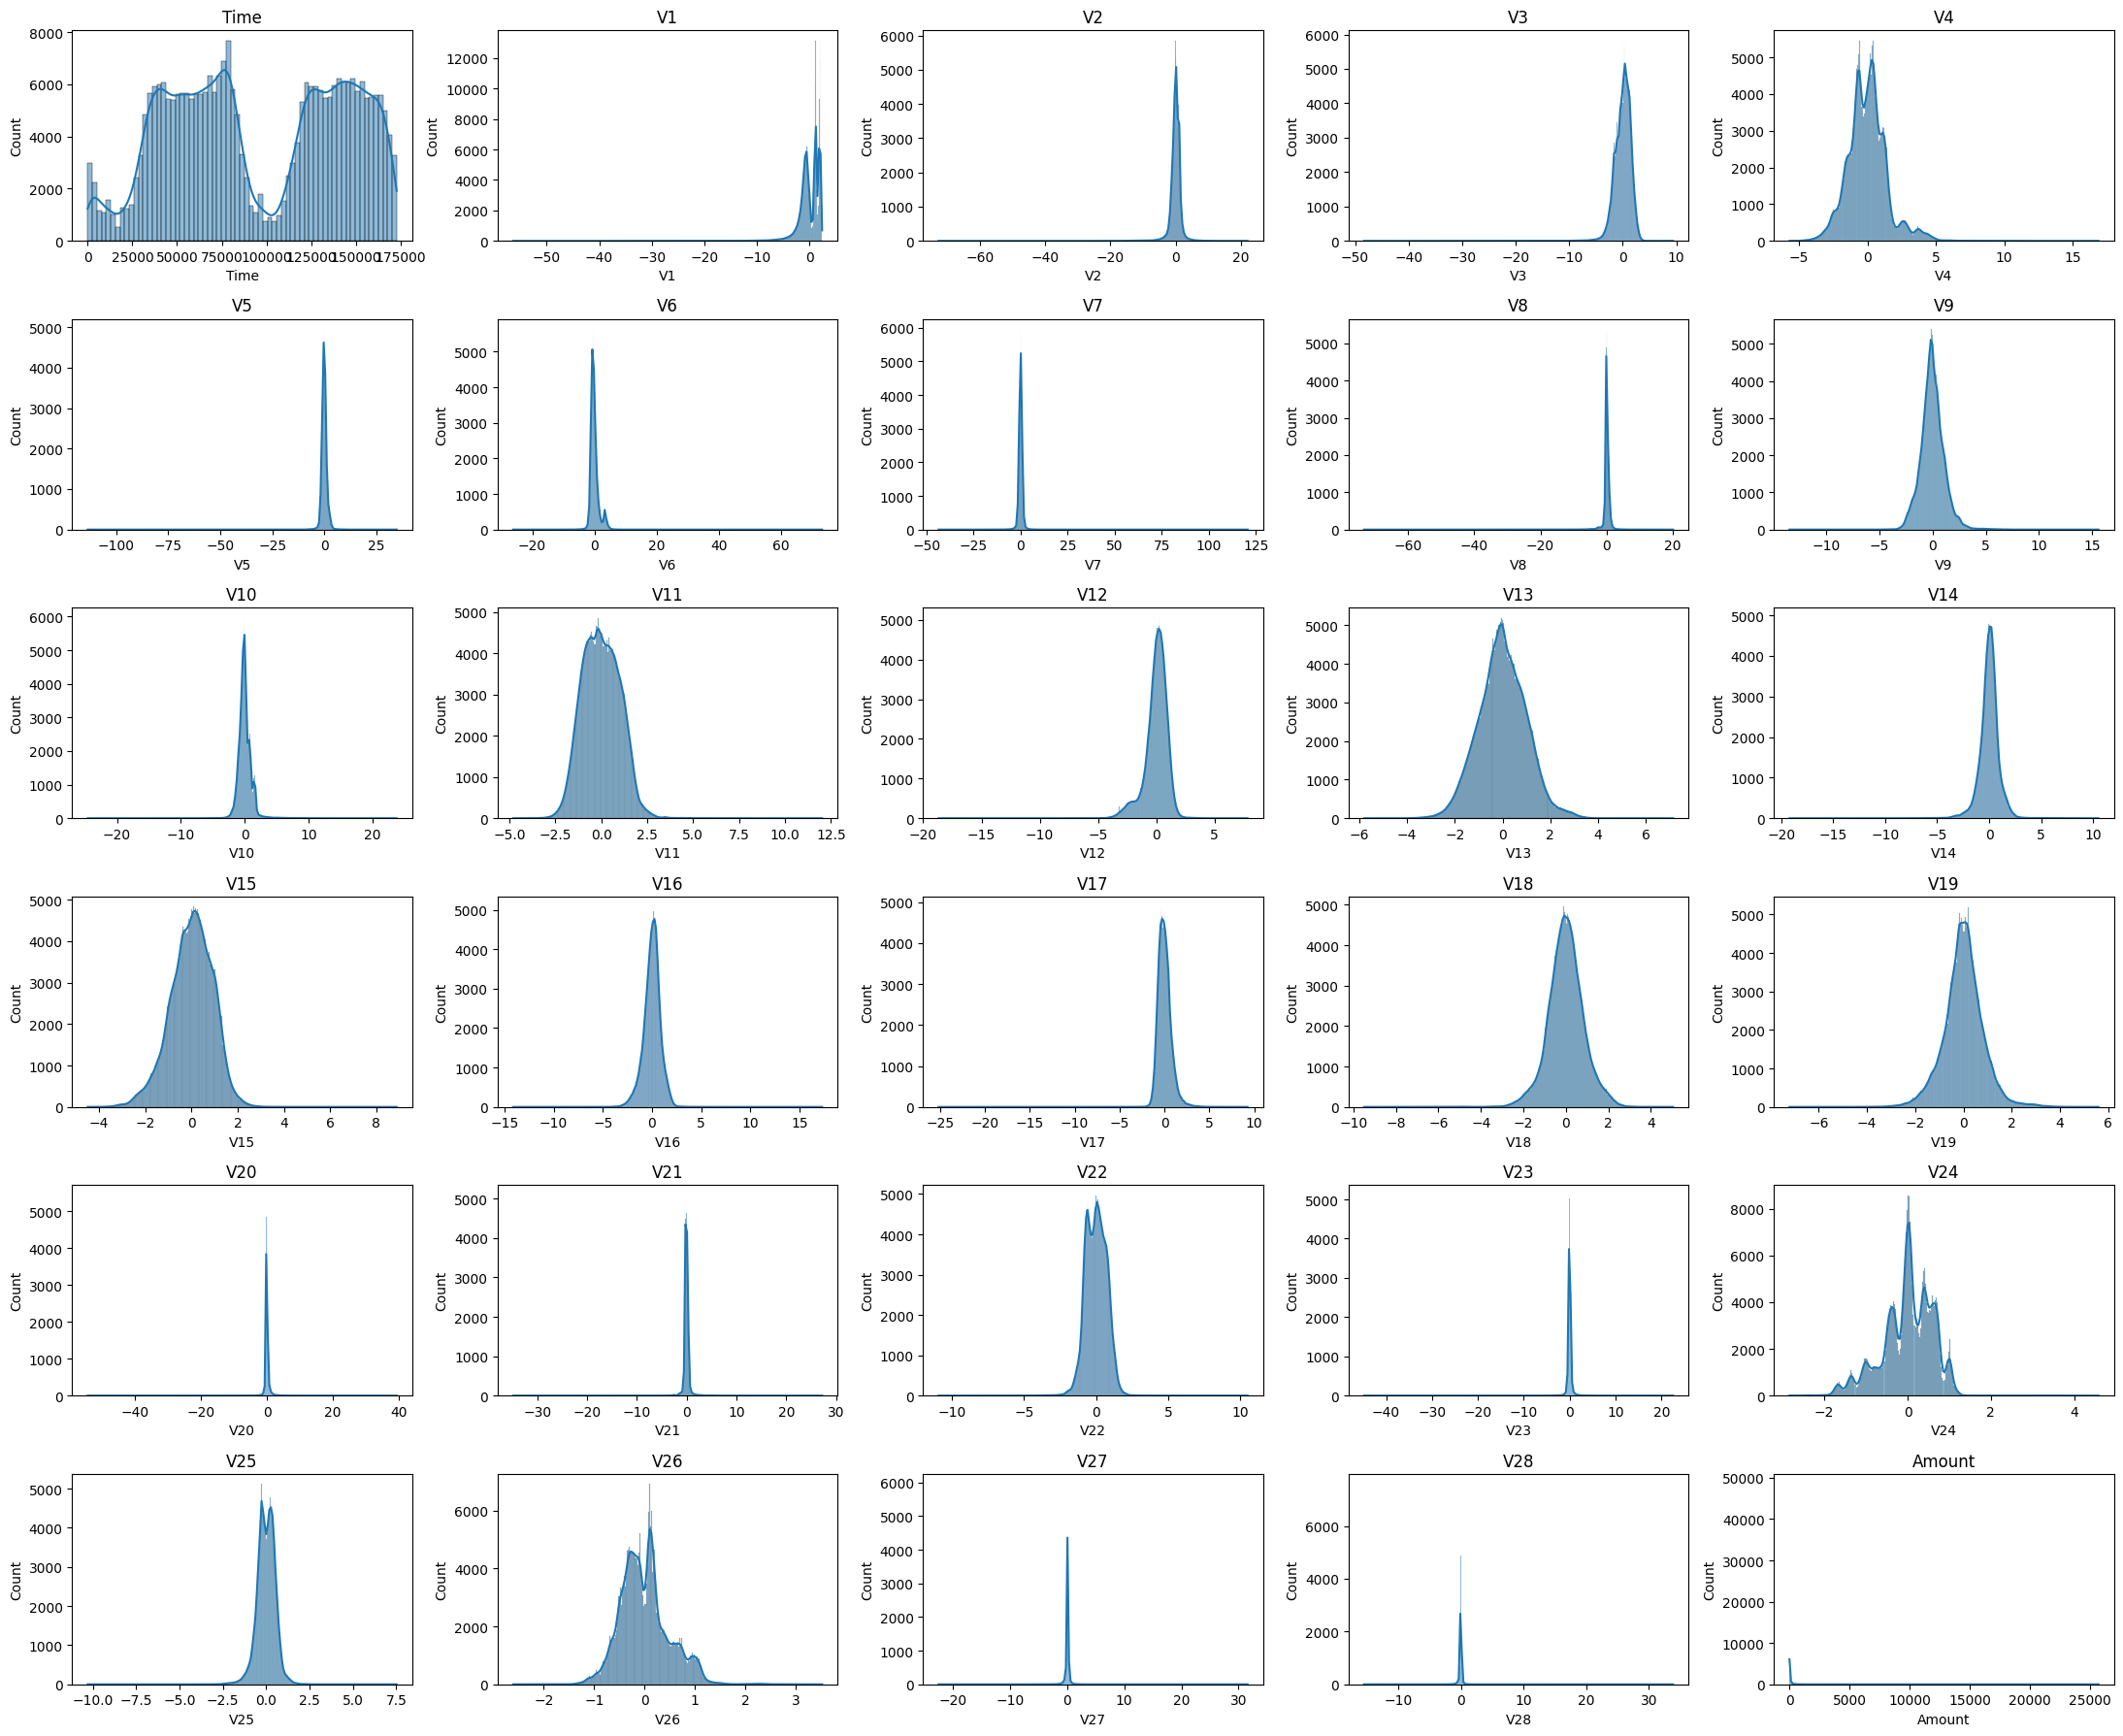

In [ ]:
columns=df.columns.tolist()[:-1]
plt.figure(figsize=(22,18))
for i in range(len(columns)):
  plt.subplot(6,5,i+1)
  sns.histplot(df[columns[i]],kde=True)
  plt.title(columns[i])
plt.tight_layout()
plt.show()

**checking the disturbution for categorical columns using countplot**

In [ ]:
df.Class.value_counts()

,count
Class,
0,283253
1,473


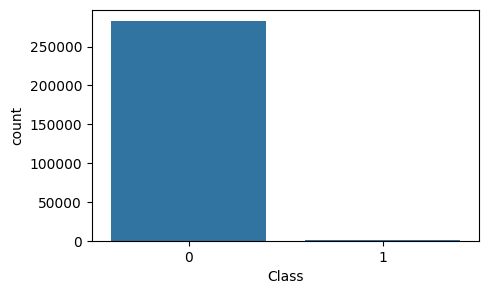

In [ ]:
plt.figure(figsize=(5,3))
sns.countplot(x="Class",data=df)
plt.show()

**our data has highly imabalance.so,we need to balance it ,before going to train the model**



**BIVARIATE ANALAYSIS**

**checking relationship between numerical features and target(categorical)**








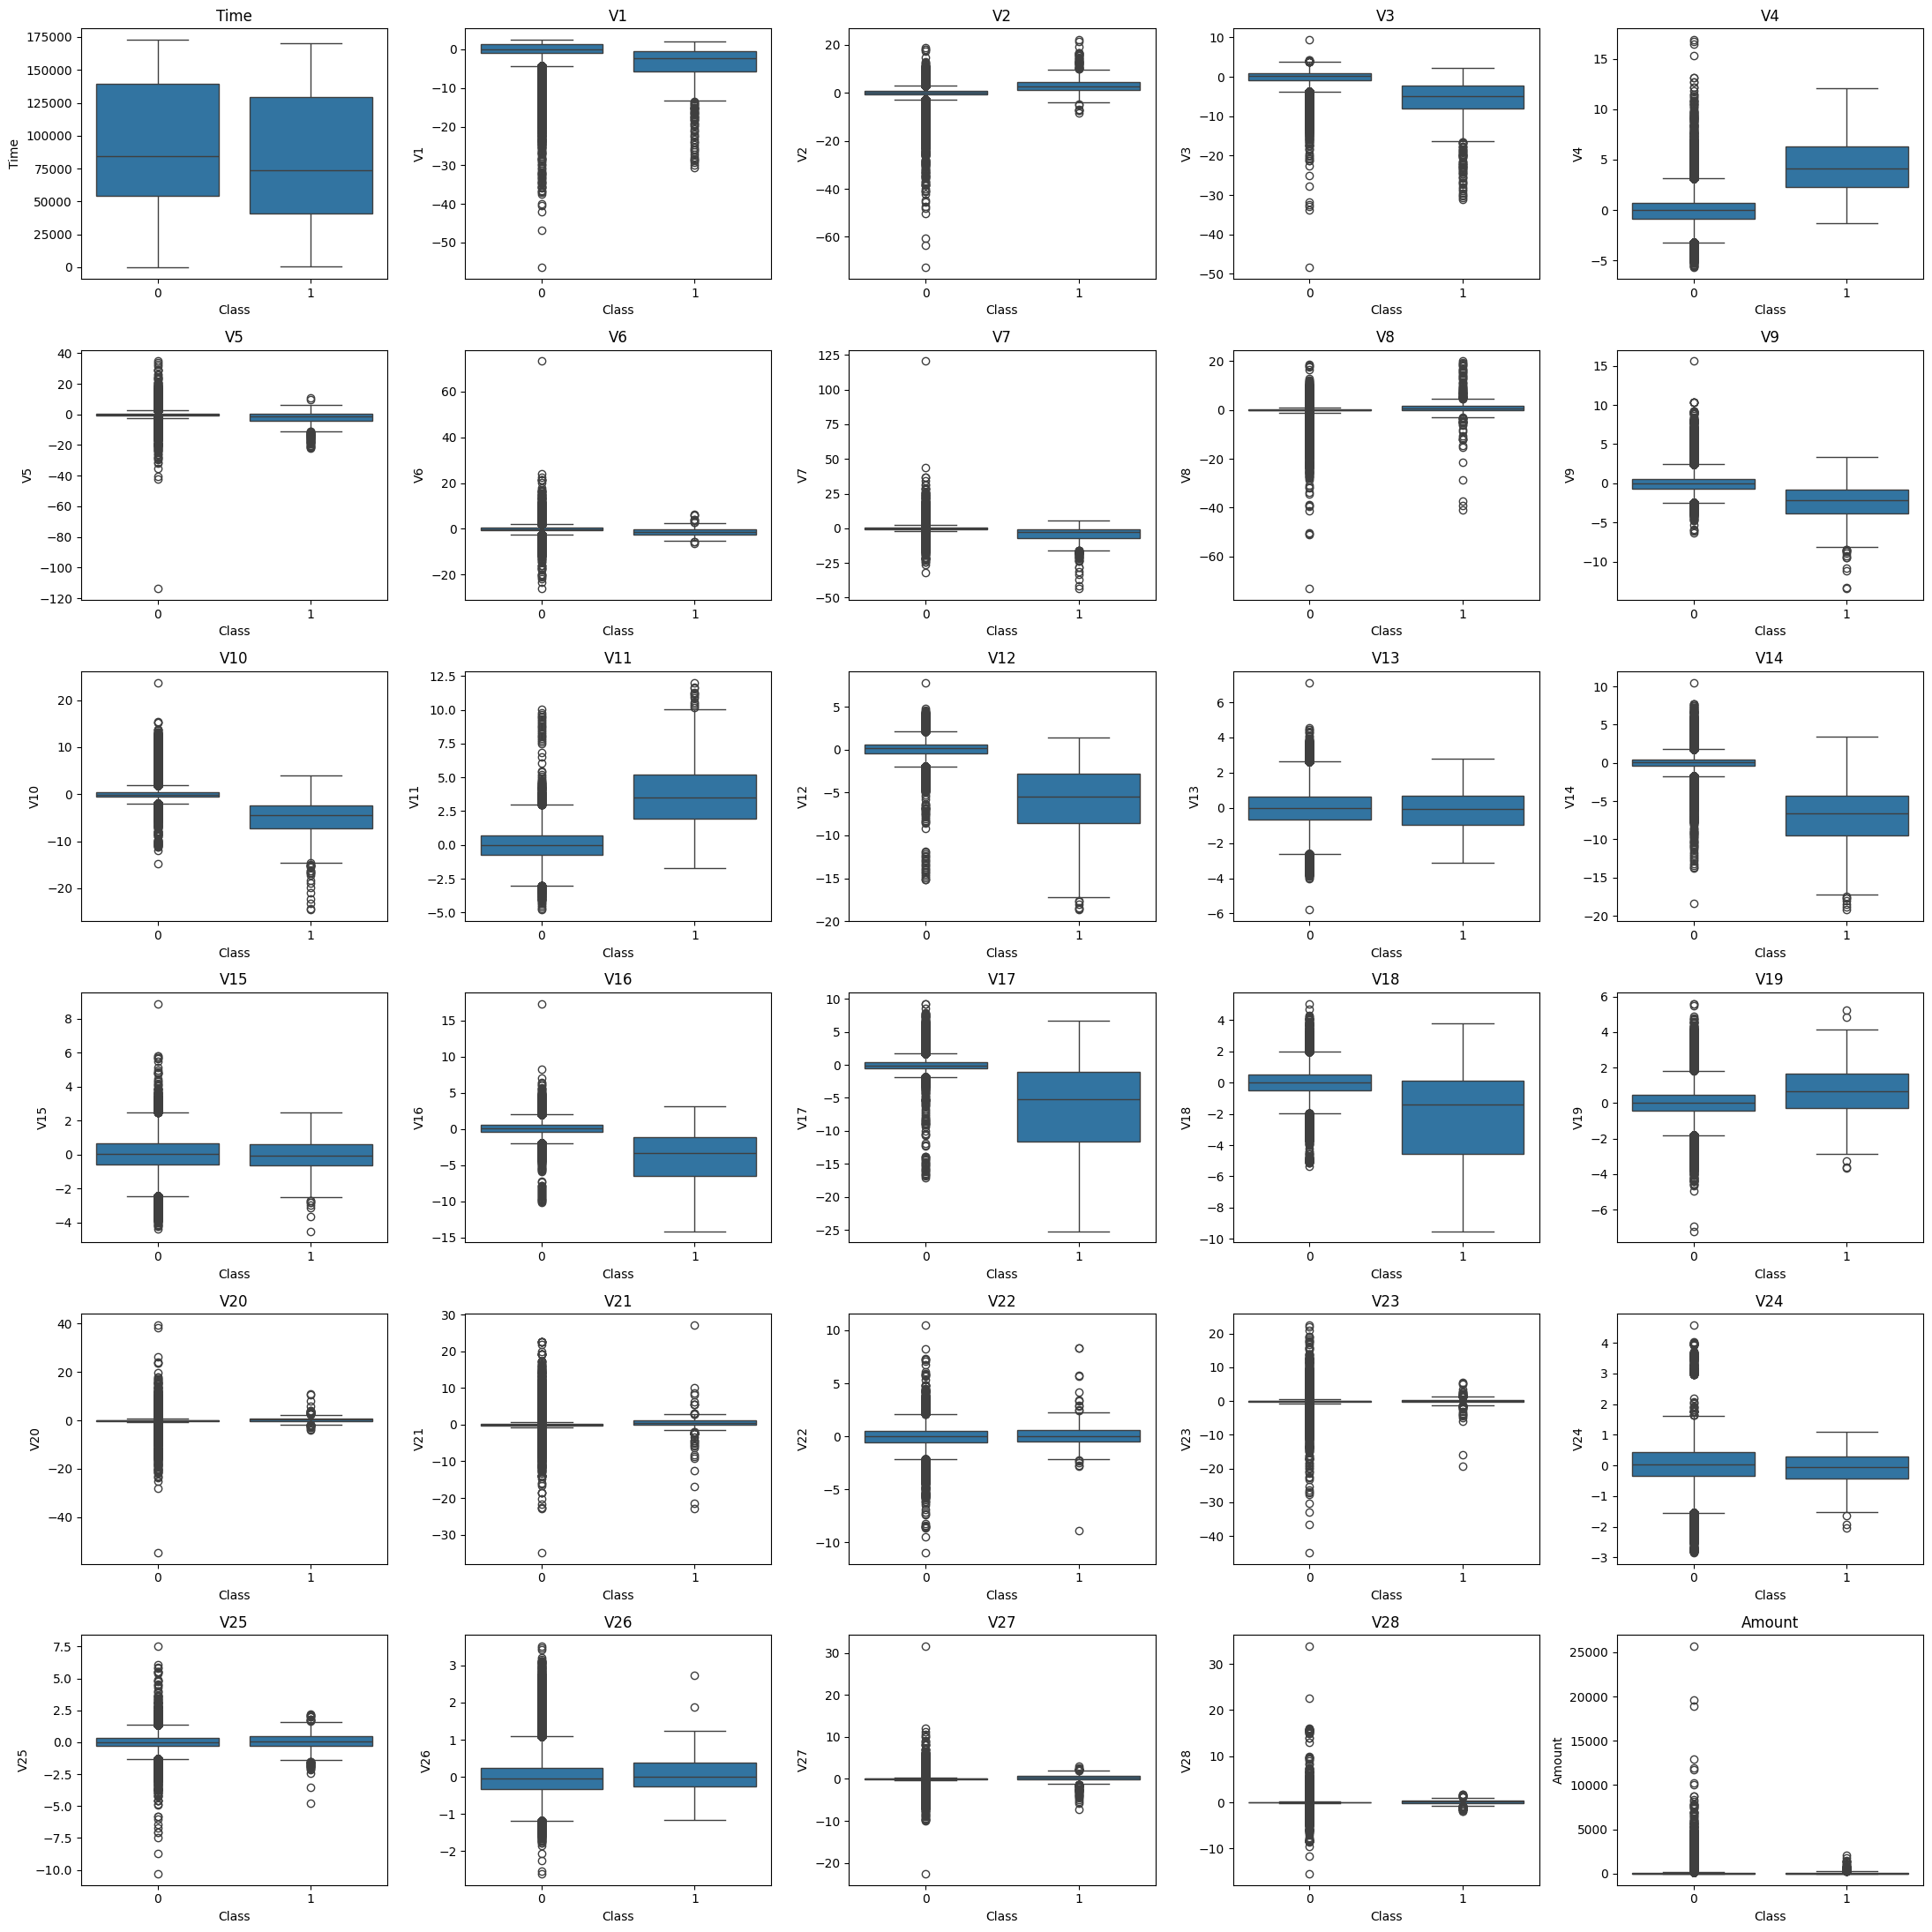

In [ ]:
columns=df.columns.tolist()[:-1]
plt.figure(figsize=(22,22))
for i in range(len(columns)):
  plt.subplot(6,5,i+1)
  sns.boxplot(x="Class",y=columns[i],data=df)
  plt.title(columns[i])
plt.tight_layout()
plt.show()

**Identifing the count of outilers in each feature**

In [ ]:
def count_outliers_by_class(df, column, class_column):
    outlier_counts = {}
    classes = df[class_column].unique()

    for cls in classes:
        class_df = df[df[class_column] == cls]
        Q1 = class_df[column].quantile(0.25)
        Q3 = class_df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = class_df[(class_df[column] < lower) | (class_df[column] > upper)]
        outlier_counts[cls] = len(outliers)

    return outlier_counts


In [ ]:
for col in df.columns.tolist():
  outlier_counts = count_outliers_by_class(df, col , 'Class')
  print(f"{col} = {outlier_counts}")


Time = {np.int64(0): 0, np.int64(1): 0}
V1 = {np.int64(0): 6810, np.int64(1): 53}
V2 = {np.int64(0): 13200, np.int64(1): 44}
V3 = {np.int64(0): 3058, np.int64(1): 56}
V4 = {np.int64(0): 10873, np.int64(1): 0}
V5 = {np.int64(0): 12061, np.int64(1): 49}
V6 = {np.int64(0): 22764, np.int64(1): 11}
V7 = {np.int64(0): 8578, np.int64(1): 42}
V8 = {np.int64(0): 23778, np.int64(1): 86}
V9 = {np.int64(0): 8028, np.int64(1): 14}
V10 = {np.int64(0): 8991, np.int64(1): 22}
V11 = {np.int64(0): 464, np.int64(1): 12}
V12 = {np.int64(0): 15010, np.int64(1): 6}
V13 = {np.int64(0): 3360, np.int64(1): 0}
V14 = {np.int64(0): 13737, np.int64(1): 7}
V15 = {np.int64(0): 2873, np.int64(1): 8}
V16 = {np.int64(0): 7928, np.int64(1): 0}
V17 = {np.int64(0): 6986, np.int64(1): 0}
V18 = {np.int64(0): 7299, np.int64(1): 0}
V19 = {np.int64(0): 10079, np.int64(1): 5}
V20 = {np.int64(0): 27447, np.int64(1): 33}
V21 = {np.int64(0): 14196, np.int64(1): 43}
V22 = {np.int64(0): 1278, np.int64(1): 17}
V23 = {np.int64(0): 183

**Correlation**

In [ ]:
df.corr()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,...,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,...,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,...,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,...,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,...,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326
V5,0.173223,-0.007036,0.005210,-0.006879,0.001744,1.000000,-0.000938,-0.008709,0.001430,-0.001213,...,0.001622,-0.000559,0.001183,0.000198,0.000069,0.000390,-0.005798,-0.000820,-0.387685,-0.087812
V6,-0.063279,0.000413,-0.000594,-0.001511,-0.000880,-0.000938,1.000000,0.000436,0.003036,-0.000734,...,-0.002134,0.001104,-0.000755,0.001202,0.000697,-0.000028,0.000289,0.000925,0.216389,-0.043915
V7,0.085335,-0.009173,0.007425,-0.011721,0.004657,-0.008709,0.000436,1.000000,-0.006419,-0.004921,...,0.009010,-0.002280,0.003303,-0.000384,-0.000072,0.000624,-0.004537,0.001657,0.400408,-0.172347
V8,-0.038203,-0.001168,0.002899,-0.001815,0.000890,0.001430,0.003036,-0.006419,1.000000,0.001038,...,0.018892,-0.006156,0.004994,0.000113,0.000011,-0.001407,0.000613,-0.000099,-0.104662,0.033068
V9,-0.007861,0.001828,-0.000274,-0.003579,0.002154,-0.001213,-0.000734,-0.004921,0.001038,1.000000,...,0.000679,0.000785,0.000677,-0.000103,-0.000275,0.001253,0.008221,0.005591,-0.044123,-0.094021


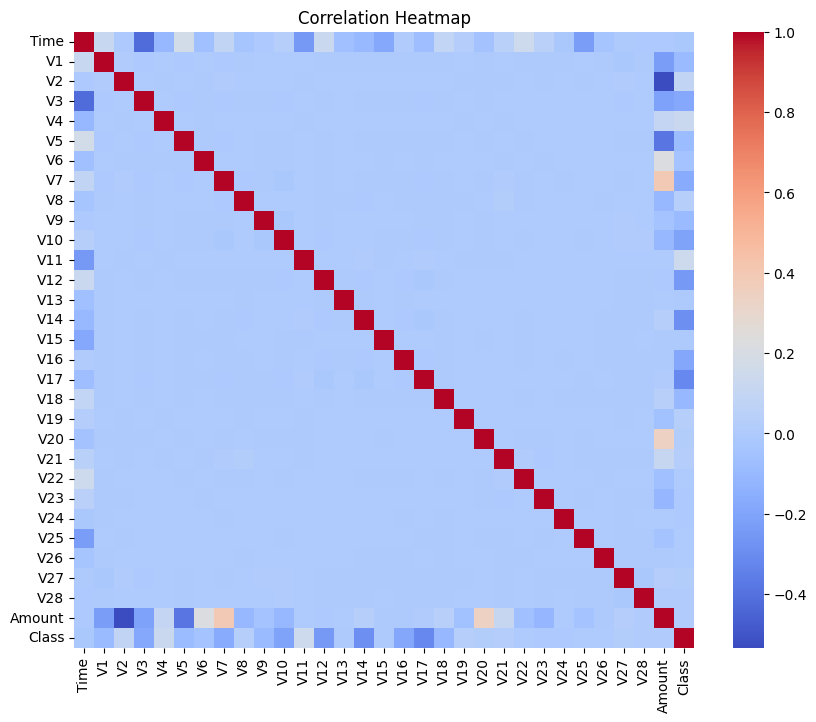

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**That means almost all the features are non-linearly related to the target variable**

#Feature selection

**IV ANALAYSIS**

**It will provides the predictive power of each feature,from this measure we can decides which is important or not**

steps 1:-Binning the numerical features with each bin atleast contains 5% data .

step 2:-calculating the WOE(weight of evidence) for each bin in a feature

step 3:-calculating the IV for each bin in a feature

step 4:-summing all the IV of each bin gives the IV of feature(predictive power)

**Binning**

In [ ]:
!pip install feature_engine

In [ ]:
from feature_engine.discretisation import EqualFrequencyDiscretiser

binning = EqualFrequencyDiscretiser(q=5,variables=df.columns.tolist()[:-1]) #each bin contains 10% of data (balanced bins,but no equal width)
df_binned = binning.fit_transform(df)

In [ ]:
df_binned

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,0,2,4,4,1,3,3,2,3,...,2,3,1,2,2,1,3,1,4,0
1,0,3,2,2,3,2,2,2,2,2,...,1,1,3,1,3,3,2,2,0,0
2,0,0,0,4,3,1,4,4,3,0,...,4,4,4,0,1,2,1,1,4,0
3,0,1,1,4,1,2,4,3,3,0,...,1,2,1,0,4,1,3,3,4,0
4,0,0,3,4,3,1,3,3,0,4,...,2,4,1,2,1,4,4,4,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,4,0,4,0,0,0,0,0,4,4,...,3,2,4,0,4,3,4,4,0,0
284803,4,1,2,4,1,4,4,2,3,3,...,3,4,2,0,0,0,3,1,2,0
284804,4,4,1,0,1,4,4,1,4,3,...,3,3,2,4,3,2,2,1,3,0
284805,4,2,3,3,3,1,3,0,4,3,...,4,4,1,2,0,4,3,4,1,0


**calculating the IV value**

In [ ]:
def calc_woe_iv(df, feature, target):
    lst = []
    for val in df[feature].unique():
        total = len(df[df[feature] == val])
        event = len(df[(df[feature] == val) & (df[target] == 1)])
        non_event = total - event
        lst.append({'Value': val, 'All': total, 'Event': event, 'Non-Event': non_event})

    data = pd.DataFrame(lst)
    data['Event Rate'] = data['Event'] / data['Event'].sum()
    data['Non-Event Rate'] = data['Non-Event'] / data['Non-Event'].sum()
    data['WOE'] = np.log(data['Event Rate'] / data['Non-Event Rate'])
    data['IV'] = (data['Event Rate'] - data['Non-Event Rate']) * data['WOE']

    iv = data['IV'].sum()
    return iv, data


In [ ]:
for col in df_binned.columns[:-1]:
  iv, details = calc_woe_iv(df_binned,col,'Class')
  print(f"IV value for {col} is {iv}")



IV value for Time is 0.12691569070852807
IV value for V1 is 1.0924027692413234
IV value for V2 is 1.6996307760397384
IV value for V3 is 2.1519104712697343
IV value for V4 is 2.879374237111267
IV value for V5 is 0.7072225201531015
IV value for V6 is 0.8703288549492517
IV value for V7 is 1.6362358475599965
IV value for V8 is 0.771919335705618
IV value for V9 is 1.3632140697992077
IV value for V10 is 2.1945064401154712
IV value for V11 is 2.176092978486558
IV value for V12 is 2.512403455960616
IV value for V13 is 0.0680000161433907
IV value for V14 is 2.9004649280134145
IV value for V15 is 0.006387622328246202
IV value for V16 is 1.8394051793303958
IV value for V17 is 1.9710241305849072
IV value for V18 is 0.9546696350220284
IV value for V19 is 0.6364279090708347
IV value for V20 is 0.6692934852960003
IV value for V21 is 1.2356749177845545
IV value for V22 is 0.010918707478113389
IV value for V23 is 0.2756525224359896
IV value for V24 is 0.10340209295616751
IV value for V25 is 0.048551044

**From the above observation,v15 and v22 are only the useless predictors ,all other features are either weak or strong predictors**

In [ ]:
df.drop(['V15','V22'],axis=1,inplace=True)

In [ ]:
df.shape

(283726, 29)

#VIF

**VIF-to detect the multicolinearity among the features**

vif=1  (no multicolinearity)

vif>5  (moderate multicolinearity)--->>potentially concern

vif>10 (highly multicolinearity )--->>remove/reduce the features

-->it takes input as numerical array ,not a df of column

--->it's a repetition process

--->Don't drop the features bindly , Before droping the feature columns check the correlation heatmap once and decide whether to drop or not ->>for feature selection(iv) and multicolinearity detection(vif)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = df.columns[:-1]
vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1]-1)]

In [ ]:
vif_data

,feature,VIF
0,Time,2.187174
1,V1,1.589990
2,V2,3.706381
3,V3,1.308818
4,V4,1.164362
5,V5,2.625995
6,V6,1.491601
7,V7,2.481116
8,V8,1.092032
9,V9,1.037031


**Almost all are with vif<5 except Amount ,we known Amount is important feature ,we are going keeping it also**

#SCALING

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
df[["Scaled_Time","Scaled_Amount"]]=scaler.fit_transform(df[["Time","Amount"]]) #Now, the entire data is centred and scaled.

In [ ]:
df.drop(["Time","Amount"],axis=1,inplace=True)

In [ ]:
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V23,V24,V25,V26,V27,V28,Class,Scaled_Time,Scaled_Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,-1.996823,0.244200
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-1.996823,-0.342584
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,-1.996802,1.158900
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,-1.996802,0.139886
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-1.996781,-0.073813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.213454,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0,1.642235,-0.350252
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.214205,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0,1.642257,-0.254325
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.232045,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0,1.642278,-0.082239
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.265245,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,0,1.642278,-0.313391


#Spliting the dataset into features and target

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']


In [ ]:
X.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V23',
       'V24', 'V25', 'V26', 'V27', 'V28', 'Scaled_Time', 'Scaled_Amount'],
      dtype='object')

In [ ]:
y

,Class
0,0
1,0
2,0
3,0
4,0
...,...
284802,0
284803,0
284804,0
284805,0


#Balancing the data

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


In [ ]:
df_balanced=pd.concat([X_resampled,y_resampled],axis=1)


In [ ]:
df_balanced

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V23,V24,V25,V26,V27,V28,Scaled_Time,Scaled_Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,-1.996823,0.244200,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-1.996823,-0.342584,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,-1.996802,1.158900,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,-1.996802,0.139886,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-1.996781,-0.073813,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566501,-7.145238,5.383562,-9.679664,7.365853,-7.135087,-3.107715,-11.258176,4.501765,-6.438760,-12.633397,...,2.215141,0.035547,0.440521,0.187297,0.525468,1.502104,0.287044,-1.129466,-0.171154,1
566502,-4.655386,8.532752,-15.222321,10.198547,-4.197514,-3.299981,-10.610038,4.919960,-5.728580,-11.811876,...,1.974833,0.482864,-1.203050,-0.340363,0.639373,1.624504,0.731982,-1.702343,-0.349333,1
566503,1.187708,3.089764,-6.134725,5.575777,1.604699,-1.933068,-0.965297,0.292589,-2.962763,-3.891017,...,0.107235,-0.058251,0.069976,0.353141,0.063025,0.479362,0.326816,0.748914,-0.353327,1
566504,-3.747533,2.528415,-4.778872,1.625306,-1.194919,-1.629738,-3.171252,1.281266,-1.645821,-4.804615,...,0.835766,-0.384040,-0.460017,-0.230811,0.581584,-0.311519,0.077275,1.139959,-0.296249,1


In [ ]:
df_balanced.Class.value_counts()

,count
Class,
0,283253
1,283253


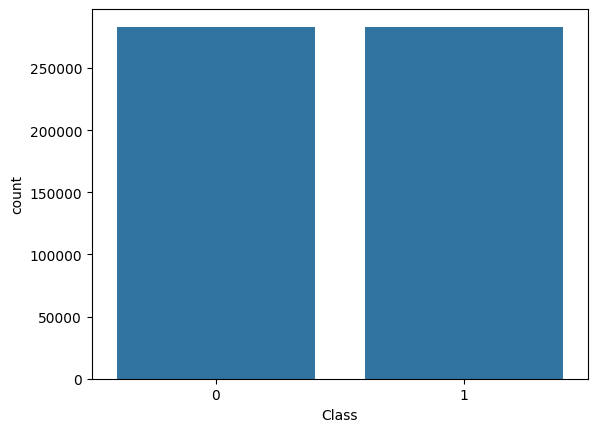

In [ ]:
sns.countplot(x="Class",data=df_balanced)
plt.show()

**Now the data is balanced**

#Model Building

**split the data for training and testing the model**

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(453204, 28)

In [ ]:
X_test.shape

(113302, 28)

**Train the logistic regression model**

In [ ]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
import statsmodels.api as sm

# Add constant for intercept
X_train_sm = sm.add_constant(X_train)

# Fit the model
model_sm = sm.Logit(y_train, X_train_sm).fit()

# Summary
print(model_sm.summary())


Optimization terminated successfully.
         Current function value: 0.139178
         Iterations 14
                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:               453204
Model:                          Logit   Df Residuals:                   453175
Method:                           MLE   Df Model:                           28
Date:                Fri, 06 Jun 2025   Pseudo R-squ.:                  0.7992
Time:                        11:14:50   Log-Likelihood:                -63076.
converged:                       True   LL-Null:                   -3.1414e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -3.5277      0.015   -239.325      0.000      -3.557      -3.499
V1                0

#Model Evalution

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("ROC_AUC score = ",roc_auc_score(y_test,model.predict_proba(X_test)[:,1]))

[[55029  1434]
 [ 4976 51863]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     56463
           1       0.97      0.91      0.94     56839

    accuracy                           0.94    113302
   macro avg       0.95      0.94      0.94    113302
weighted avg       0.95      0.94      0.94    113302

ROC_AUC score =  0.9877137374551528


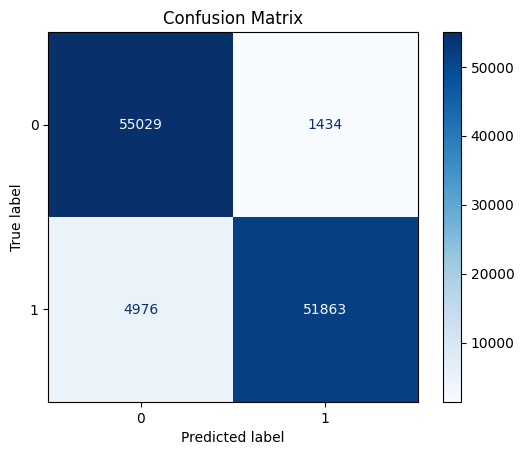

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="Blues",values_format="d")
plt.title("Confusion Matrix")
plt.show()

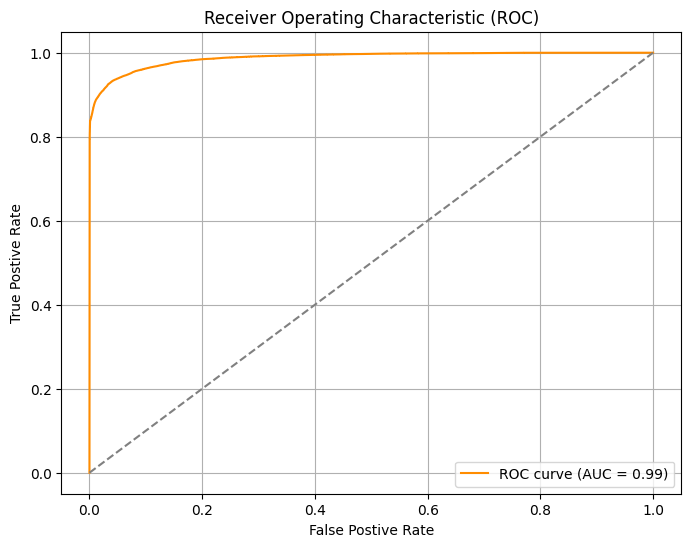

In [ ]:
from sklearn.metrics import roc_curve,auc

fpr,tpr,thersholds=roc_curve(y_test,model.predict_proba(X_test)[:,1])
roc_auc=auc(fpr,tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"ROC curve (AUC = {roc_auc:.2f})",color='darkorange')
plt.plot([0,1],[0,1],linestyle="--",color="gray")
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel("False Postive Rate")
plt.ylabel("True Postive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

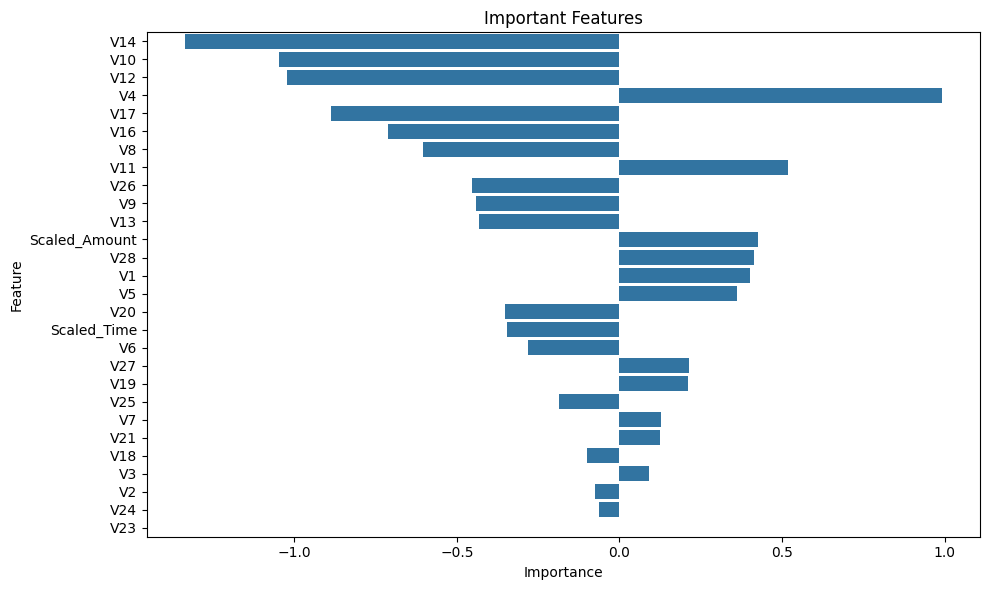

In [ ]:
importance = model.coef_[0]
features = X_train.columns

# Creating a DataFrame
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', key=abs, ascending=False)



plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Important Features')
plt.tight_layout()
plt.show()


#checking overfitting and underfitting

In [ ]:
from sklearn.metrics import accuracy_score
#  Evaluate on Training Data
train_preds = model.predict(X_train)
train_acc = accuracy_score(y_train, train_preds)
print("Training Accuracy:", train_acc)

# Evaluate on Testing Data
test_preds = model.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9439832834661653
Testing Accuracy: 0.9434255352950521


**since the values are very close ,there  is no overfitting and underfitting**

#saving the model

In [ ]:
import joblib

# Save the model to a file
joblib.dump(model, 'credit_card_fraud_model.pkl')




['credit_card_fraud_model.pkl']